# Question 1 Can we classify lineups as “elite,” “average,” or “struggling” solely based on their archetype composition?

In [1]:
# 1. Imports

import os
from collections import Counter

import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score

)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight


import matplotlib.pyplot as plt
import seaborn as sns


LINEUP_DIR = "NBA5ManLineupStats"
ARCHETYPE_DIR = "NBAPlayerArchetypesAssigned"

In [2]:
# 2. Helper Functions (Name Parsing/Matching)
SUFFIXES = {"Jr.", "Sr.", "II", "III", "IV", "V"}

def core_last_name_from_full(name: str) -> str:
   
    parts = str(name).strip().split()
    if not parts:
        return ""
    # Handle suffixes like Jr., Sr., III
    if len(parts) >= 2 and parts[-1] in SUFFIXES:
        return parts[-2]
    return parts[-1]

def core_last_name_from_abbrev(name: str) -> str:
    """
    For an abbreviated lineup name like:
      'S. Gilgeous-Alexander'-> 'Gilgeous-Alexander'
    """
    parts = str(name).strip().split()
    if len(parts) <= 1:
        return ""
    # Ignore the first token (initial + '.')
    rest = parts[1:]
    # Strip suffix tokens at the end
    while len(rest) > 1 and rest[-1] in SUFFIXES:
        rest = rest[:-1]
    return rest[-1]

def first_initial_from_full(name: str) -> str:
    parts = str(name).strip().split()
    return parts[0][0].upper() if parts else ""

def first_initial_from_abbrev(name: str) -> str:
    parts = str(name).strip().split()
    if not parts:
        return ""
    return parts[0][0].upper()  # 'C.' -> 'C'

def preprocess_archetype_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["LastKey"] = df["Player"].apply(core_last_name_from_full).str.lower()
    df["FirstInitial"] = df["Player"].apply(first_initial_from_full)
    return df

def match_player_to_archetype(player_abbrev: str, team: str, arche_df: pd.DataFrame) -> str:
    last_key = core_last_name_from_abbrev(player_abbrev).lower()
    first_init = first_initial_from_abbrev(player_abbrev)

    if not last_key:
        return "Unknown"

    # All players with matching last name
    candidates = arche_df[arche_df["LastKey"] == last_key]

    # Same team & same initial
    if team is not None:
        c1 = candidates[
            (candidates["Team"] == team) &
            (candidates["FirstInitial"] == first_init)
        ]
        if not c1.empty:
            return c1.iloc[0]["Archetype"]

    # Any team, same initial
    c2 = candidates[candidates["FirstInitial"] == first_init]
    if not c2.empty:
        return c2.iloc[0]["Archetype"]

    # Any team, just last name
    if not candidates.empty:
        return candidates.iloc[0]["Archetype"]

    
    return "Unknown"

def extract_players_from_lineup(lineup_str: str):
    
    # Split the 'Lineups' string into a list of player abbreviations
    if pd.isna(lineup_str):
        return []
    return [p.strip() for p in str(lineup_str).split(" - ") if p.strip()]

In [3]:
# 3. Load Archetype Tables for All Seasons

archetypes_by_season = {}
all_archetypes_seen = set()

for file in os.listdir(ARCHETYPE_DIR):
    if not file.endswith(".csv"):
        continue

    
    season = file.split("(")[1].split(")")[0]

    path = os.path.join(ARCHETYPE_DIR, file)
    df_arch = pd.read_csv(path)

    # Player, Team, Pos, Archetype columns
    df_arch = preprocess_archetype_df(df_arch)
    archetypes_by_season[season] = df_arch

    all_archetypes_seen.update(df_arch["Archetype"].dropna().unique())

# One feature column per archetype
all_archetypes_sorted = sorted(all_archetypes_seen)

print("Loaded archetypes for seasons:", sorted(archetypes_by_season.keys()))
print("Total unique archetypes:", len(all_archetypes_sorted))
# print("\n=== Unique Archetypes Detected ===")
# for a in all_archetypes_sorted:
#     print("-", a)


Loaded archetypes for seasons: ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
Total unique archetypes: 18


In [4]:
# 4. Build Lineup Dataset with Archetype Counts

lineup_rows = []

for file in os.listdir(LINEUP_DIR):
    if not file.endswith(".csv"):
        continue

    season = file.split("(")[1].split(")")[0]
    print(f"Processing lineups for season {season}...")

    if season not in archetypes_by_season:
        print(f"  WARNING: no archetype file found for season {season}, skipping.")
        continue

    df_lineups = pd.read_csv(os.path.join(LINEUP_DIR, file))
    arch_df = archetypes_by_season[season]

    for _, row in df_lineups.iterrows():
        lineup_str = row["Lineups"]
        team = row.get("TEAM", None)
        net_rtg = row.get("NetRtg", np.nan)
        min_played = row.get("MIN", np.nan)
        gp = row.get("GP", np.nan)

        players = extract_players_from_lineup(lineup_str)
        arche_list = []

        for p in players:
            arche = match_player_to_archetype(p, team, arch_df)
            arche_list.append(arche)

        counts = Counter(arche_list)

        feature_dict = {
            f"count_{a}": counts.get(a, 0) for a in all_archetypes_sorted
        }

        feature_dict.update({
            "Season": season,
            "TEAM": team,
            "Lineups": lineup_str,
            "GP": gp,
            "MIN": min_played,
            "NetRtg": net_rtg,
        })

        lineup_rows.append(feature_dict)

lineup_df = pd.DataFrame(lineup_rows)

# Drop rows without NetRtg
lineup_df = lineup_df.dropna(subset=["NetRtg"]).reset_index(drop=True)

# Ensure both columns exist; if a type never appeared, fill with 0
for col in ["count_Unknown", "count_Unclassified"]:
    if col not in lineup_df.columns:
        lineup_df[col] = 0

# Count how many “bad” archetypes are in each lineup
lineup_df["UnknownCount"] = lineup_df[["count_Unknown", "count_Unclassified"]].sum(axis=1)

# Keep only lineups with at most 2 Unknown/Unclassified players
lineup_df = lineup_df[lineup_df["UnknownCount"] <= 2].copy()

# Filter out super low-minute lineups
MIN_MINUTES = 50
lineup_df = lineup_df[lineup_df["MIN"] >= MIN_MINUTES].copy()

print(f"After filtering, remaining lineups: {len(lineup_df)}")

Processing lineups for season 2022-23...
Processing lineups for season 2021-22...
Processing lineups for season 2023-24...
Processing lineups for season 2020-21...
Processing lineups for season 2024-25...
After filtering, remaining lineups: 1381


In [5]:
# 5. Interaction features, synergy features, team/season

def add_interaction_terms(df: pd.DataFrame) -> pd.DataFrame:
    
    # interactions between archetype counts.
    
    combos = [
        ("count_Shooter", "count_Interior Creator"),
        ("count_Shooter", "count_Lead Playmaker"),
        ("count_3&D Specialist", "count_Lead Playmaker"),
        ("count_Rim running shotblocker", "count_Switchable defender"),
        ("count_2 Way Player", "count_Switchable defender"),
    ]

    df = df.copy()
    for a, b in combos:
        if a in df.columns and b in df.columns:
            new_col = f"{a}_x_{b}"
            df[new_col] = df[a] * df[b]
    return df


def add_synergy_features(df: pd.DataFrame) -> pd.DataFrame:
   
    df = df.copy()

    def c(name: str):
        col = f"count_{name}"
        return df[col] if col in df.columns else 0

    creators_primary = (
        c("Lead Playmaker") +
        c("Interior Creator") +
        c("Point Forward")
    )

    creators_secondary = (
        c("Secondary Playmaker") +
        c("Playmaking forward")
    )

    shooters = (
        c("Shooter") +
        c("3&D Specialist") +
        c("Combo Guard") +
        c("2 Way Player")
    )

    rim_protection = (
        c("Rim running shotblocker") +
        c("Switchable defender")
    )

    on_ball_defenders = (
        c("Pitbull") +
        c("3&D Specialist") +
        c("2 Way Player") +
        c("Switchable defender")
    )

    finishers = (
        c("Athletic finisher") +
        c("Rim running shotblocker")
    )

    # binary flags
    df["has_primary_creator"]    = (creators_primary >= 1).astype(int)
    df["has_two_creators"]       = (creators_primary + creators_secondary >= 2).astype(int)
    df["has_two_shooters"]       = (shooters >= 2).astype(int)
    df["has_rim_protection"]     = (rim_protection >= 1).astype(int)
    df["has_two_rim_protectors"] = (rim_protection >= 2).astype(int)
    df["has_onball_defense"]     = (on_ball_defenders >= 1).astype(int)
    df["has_two_onball_def"]     = (on_ball_defenders >= 2).astype(int)
    df["has_finisher"]           = (finishers >= 1).astype(int)

    # numeric counts, ratios
    df["num_creators"]   = (creators_primary + creators_secondary)
    df["num_shooters"]   = shooters
    df["num_defenders"]  = on_ball_defenders

    df["creator_to_shooter_ratio"] = df["num_creators"] / (df["num_shooters"] + 1e-6)
    df["creator_to_def_ratio"]     = df["num_creators"] / (df["num_defenders"] + 1e-6)

    return df


lineup_df = add_interaction_terms(lineup_df)
lineup_df = add_synergy_features(lineup_df)

# One-hot encode team and season
lineup_df = pd.get_dummies(lineup_df, columns=["TEAM"], drop_first=True)
lineup_df = pd.get_dummies(lineup_df, columns=["Season"], drop_first=True)

print("Lineup_df columns:", len(lineup_df.columns))

Lineup_df columns: 75


In [6]:
# 6. Define Smoothed Global Tiers Using NetRtg 

# global z-score for NetRtg across ALL seasons
mean_netrtg = lineup_df["NetRtg"].mean()
std_netrtg = lineup_df["NetRtg"].std()
lineup_df["NetRtg_z"] = (lineup_df["NetRtg"] - mean_netrtg) / std_netrtg

ELITE_Z = 0.80
STRUG_Z = -0.80

def assign_smoothed_tier(z):
    if z >= ELITE_Z:
        return "Elite"
    elif z <= STRUG_Z:
        return "Struggling"
    else:
        return "Average"

lineup_df["Tier"] = lineup_df["NetRtg_z"].apply(assign_smoothed_tier)

print("Smoothed class distribution:")
print(lineup_df["Tier"].value_counts())

Smoothed class distribution:
Tier
Average       848
Elite         271
Struggling    262
Name: count, dtype: int64


In [7]:
# 7. Features + Train/Test Split

count_cols = [c for c in lineup_df.columns if c.startswith("count_")]
synergy_cols = [
    c for c in lineup_df.columns
    if c.startswith("has_") or c.startswith("num_") or c.endswith("_ratio")
]
interaction_cols = [c for c in lineup_df.columns if "_x_" in c]
team_cols   = [c for c in lineup_df.columns if c.startswith("TEAM_")]
season_cols = [c for c in lineup_df.columns if c.startswith("Season_")]

feature_cols = count_cols + synergy_cols + interaction_cols + team_cols + season_cols

print("Num count features:", len(count_cols))
print("Num synergy features:", len(synergy_cols))
print("Num interaction features:", len(interaction_cols))
print("Num TEAM features:", len(team_cols))
print("Num Season features:", len(season_cols))
print("Total features:", len(feature_cols))

X = lineup_df[feature_cols].values
y = lineup_df["Tier"].values

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y,
    lineup_df.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)

train_df = lineup_df.loc[train_idx].copy()
test_df  = lineup_df.loc[test_idx].copy()

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Num count features: 24
Num synergy features: 13
Num interaction features: 5
Num TEAM features: 29
Num Season features: 4
Total features: 75
Train size: 1104
Test size: 277


In [8]:
# 8. Tuned Gradient Boosting Trees


gb_base = GradientBoostingClassifier(random_state=42)

gb_param_dist = {
    "n_estimators":    [200, 300, 400, 500, 600],
    "learning_rate":   [0.03, 0.05, 0.07, 0.1],
    "max_depth":       [2, 3, 4],
    "min_samples_leaf":[1, 2, 3],
    "min_samples_split":[2, 4, 6],
    "subsample":       [0.8, 0.9, 1.0],
}

# minutes * class_balance weights
class_weights_train = compute_sample_weight(class_weight="balanced", y=train_df["Tier"])
train_weights = train_df["MIN"].values * class_weights_train

gb_search = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=gb_param_dist,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

gb_search.fit(X_train, y_train, sample_weight=train_weights)

print("Best GB CV accuracy:", gb_search.best_score_)
print("Best GB params:", gb_search.best_params_)

gb = gb_search.best_estimator_
gb.fit(X_train, y_train, sample_weight=train_weights)

gb_pred = gb.predict(X_test)

print("\n=== Tuned GradientBoosting Test Performance (base) ===")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

test_df["Tier_pred_base"] = gb_pred

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best GB CV accuracy: 0.47208573887609456
Best GB params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.03}

=== Tuned GradientBoosting Test Performance (base) ===
Accuracy: 0.516245487364621
              precision    recall  f1-score   support

     Average       0.64      0.64      0.64       170
       Elite       0.33      0.41      0.36        54
  Struggling       0.32      0.25      0.28        53

    accuracy                           0.52       277
   macro avg       0.43      0.43      0.43       277
weighted avg       0.52      0.52      0.51       277



In [9]:
# 9. Tuning to increase elite/struggling recall score

proba_base = gb.predict_proba(X_test)
classes = list(gb.classes_)
idx_elite = classes.index("Elite")
idx_strug = classes.index("Struggling")

results = []

alpha_elite_grid = np.arange(1.0, 2.1, 0.1)
alpha_strug_grid = np.arange(1.0, 2.1, 0.1)

for ae in alpha_elite_grid:
    for asg in alpha_strug_grid:
        proba = proba_base.copy()
        proba[:, idx_elite] *= ae
        proba[:, idx_strug] *= asg

        y_pred_tmp = np.array(classes)[proba.argmax(axis=1)]

        report = classification_report(
            y_test, y_pred_tmp, output_dict=True, zero_division=0
        )
        acc        = report["accuracy"]
        elite_rec  = report["Elite"]["recall"]
        strug_rec  = report["Struggling"]["recall"]
        macro_f1   = f1_score(y_test, y_pred_tmp, average="macro")

        results.append({
            "alpha_elite": ae,
            "alpha_strug": asg,
            "accuracy": acc,
            "macro_f1": macro_f1,
            "elite_recall": elite_rec,
            "strug_recall": strug_rec,
            "y_pred": y_pred_tmp
        })

results_df = pd.DataFrame(results)

# targets
ACC_FLOOR   = 0.40   
ELITE_MIN   = 0.30
STRUG_MIN   = 0.25

good = results_df[
    (results_df["elite_recall"] >= ELITE_MIN) &
    (results_df["strug_recall"] >= STRUG_MIN) &
    (results_df["accuracy"] >= ACC_FLOOR)
]

if not good.empty:
    best_row = good.sort_values(["macro_f1", "accuracy"], ascending=False).iloc[0]
else:
    best_row = results_df.sort_values(
        ["elite_recall", "strug_recall"], ascending=False
    ).iloc[0]

print("\n=== Chosen threshold tuning config ===")
print(best_row[["alpha_elite", "alpha_strug",
                "accuracy", "macro_f1",
                "elite_recall", "strug_recall"]])

y_pred_final = best_row["y_pred"]
test_df["Tier_pred"] = y_pred_final  # final predictions used everywhere below


=== Chosen threshold tuning config ===
alpha_elite          1.0
alpha_strug          1.3
accuracy        0.509025
macro_f1        0.439721
elite_recall     0.37037
strug_recall    0.377358
Name: 3, dtype: object


In [10]:
# 10. 5-fold cross validation with tuned GB 

X_all = lineup_df[feature_cols].values
y_all = lineup_df["Tier"].values
w_all = compute_sample_weight(class_weight="balanced", y=y_all) * lineup_df["MIN"].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

best_gb_params = gb_search.best_params_

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_all, y_all), start=1):
    X_tr, X_va = X_all[tr_idx], X_all[va_idx]
    y_tr, y_va = y_all[tr_idx], y_all[va_idx]
    w_tr       = w_all[tr_idx]

    gb_cv = GradientBoostingClassifier(**best_gb_params, random_state=42 + fold)
    gb_cv.fit(X_tr, y_tr, sample_weight=w_tr)
    y_va_pred = gb_cv.predict(X_va)
    cv_scores.append(accuracy_score(y_va, y_va_pred))

print("\n=== 5-fold CV: Gradient Boosting (tuned) ===")
print("Fold accuracies:", cv_scores)
print("Mean accuracy:  {:.3f}".format(np.mean(cv_scores)))
print("Std dev:        {:.3f}".format(np.std(cv_scores)))


=== 5-fold CV: Gradient Boosting (tuned) ===
Fold accuracies: [0.5415162454873647, 0.5398550724637681, 0.5797101449275363, 0.5398550724637681, 0.5072463768115942]
Mean accuracy:  0.542
Std dev:        0.023


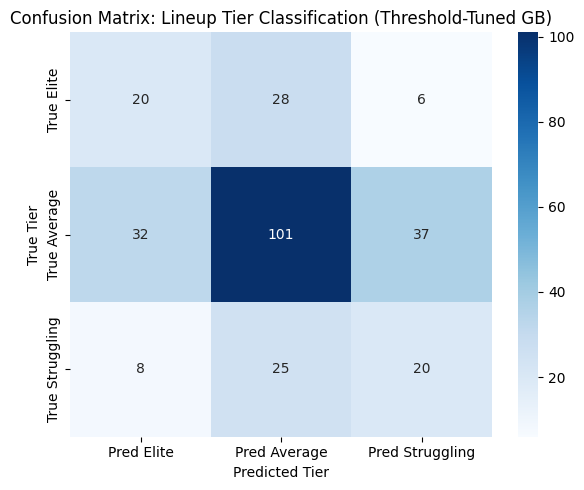

In [11]:
# 13. Confusion Matrix 

labels = ["Elite", "Average", "Struggling"]

cm = confusion_matrix(
    y_test,
    test_df["Tier_pred"],   
    labels=labels
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[f"Pred {l}" for l in labels],
    yticklabels=[f"True {l}" for l in labels],
    cmap="Blues"
)
plt.title("Confusion Matrix: Lineup Tier Classification (Threshold-Tuned GB)")
plt.ylabel("True Tier")
plt.xlabel("Predicted Tier")
plt.tight_layout()
plt.show()

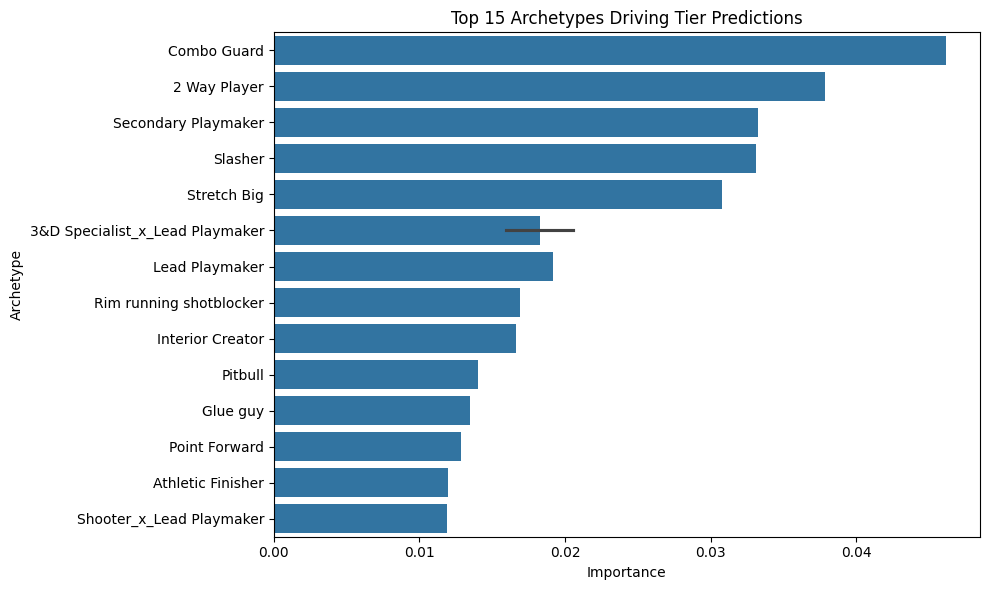

In [12]:
# 14. Feature Importance 


# All features
importances = gb.feature_importances_
imp_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values("Importance", ascending=False)


# Archetype only importances 
arch_cols = [c for c in feature_cols if c.startswith("count_")]
arch_imp = imp_df[imp_df["Feature"].isin(arch_cols)].copy()
arch_imp["Archetype"] = arch_imp["Feature"].str.replace("count_", "", regex=False)
arch_imp = arch_imp.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=arch_imp.head(15),
    x="Importance",
    y="Archetype"
)
plt.title("Top 15 Archetypes Driving Tier Predictions")
plt.tight_layout()
plt.show()

Using 17 individual archetype columns.

Average archetype counts per lineup by tier (individual archetypes only):


,count_2 Way Player,count_3&D Specialist,count_Athletic Finisher,count_Combo Guard,count_Glue guy,count_Interior Creator,count_Lead Playmaker,count_Microwave,count_Pitbull,count_Playmaking forward,count_Point Forward,count_Rim running shotblocker,count_Secondary Playmaker,count_Shooter,count_Slasher,count_Stretch Big,count_Switchable defender
Tier,,,,,,,,,,,,,,,,,
Elite,0.571956,0.232472,0.121771,0.490775,0.107011,0.276753,0.494465,0.062731,0.154982,0.018450,0.173432,0.671587,0.302583,0.254613,0.169742,0.243542,0.357934
Average,0.389151,0.245283,0.152123,0.597877,0.100236,0.318396,0.536557,0.077830,0.120283,0.050708,0.205189,0.622642,0.234670,0.253538,0.271226,0.191038,0.299528
Struggling,0.301527,0.209924,0.198473,0.744275,0.148855,0.248092,0.465649,0.049618,0.114504,0.053435,0.179389,0.595420,0.251908,0.290076,0.274809,0.244275,0.278626



=== Archetypes most over-represented in ELITE lineups ===


,Elite_minus_Struggling
2 Way Player,0.270429
Switchable defender,0.079308
Rim running shotblocker,0.076167
Secondary Playmaker,0.050675
Pitbull,0.040478
Lead Playmaker,0.028816
Interior Creator,0.028661
3&D Specialist,0.022549
Microwave,0.013112
Stretch Big,-0.000732



=== Archetypes most over-represented in STRUGGLING lineups ===


,Elite_minus_Struggling
3&D Specialist,0.022549
Microwave,0.013112
Stretch Big,-0.000732
Point Forward,-0.005958
Playmaking forward,-0.034985
Shooter,-0.035464
Glue guy,-0.041844
Athletic Finisher,-0.076702
Slasher,-0.105067
Combo Guard,-0.253500


<Figure size 1200x600 with 0 Axes>

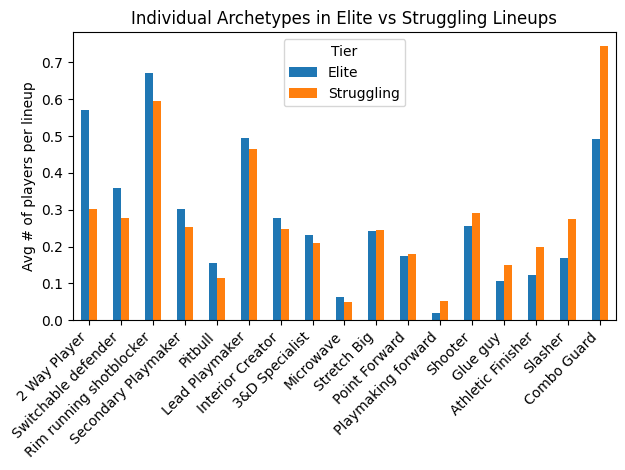

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Identify *individual* archetype count columns
#    (exclude interaction / synergy count columns)
# ------------------------------------------------------------
count_cols = [
    c for c in lineup_df.columns
    if c.startswith("count_")
    and "_x_" not in c          # drop interaction features like count_A_x_count_B
]

# Explicitly drop "bad" buckets if present
for bad in ["count_Unknown", "count_Unclassified"]:
    if bad in count_cols:
        count_cols.remove(bad)

print(f"Using {len(count_cols)} individual archetype columns.")

# ------------------------------------------------------------
# 2. Average archetype counts by lineup tier
# ------------------------------------------------------------
tier_order = ["Elite", "Average", "Struggling"]

tier_means = (
    lineup_df
    .groupby("Tier")[count_cols]
    .mean()
    .reindex(tier_order)
)

print("\nAverage archetype counts per lineup by tier (individual archetypes only):")
display(tier_means)

# ------------------------------------------------------------
# 3. Elite vs Struggling differences
# ------------------------------------------------------------
elite_means  = tier_means.loc["Elite"]
strugg_means = tier_means.loc["Struggling"]

diff_elite_minus_strugg = (elite_means - strugg_means).sort_values(ascending=False)

top_elite_lean   = diff_elite_minus_strugg.head(10)
top_strugg_lean  = diff_elite_minus_strugg.tail(10)

print("\n=== Archetypes most over-represented in ELITE lineups ===")
display(
    top_elite_lean
    .rename(lambda s: s.replace("count_", ""))
    .to_frame("Elite_minus_Struggling")
)

print("\n=== Archetypes most over-represented in STRUGGLING lineups ===")
display(
    top_strugg_lean
    .rename(lambda s: s.replace("count_", ""))
    .to_frame("Elite_minus_Struggling")
)

# ------------------------------------------------------------
# 4. Bar chart: Elite vs Struggling for key individual archetypes
# ------------------------------------------------------------
selected_cols = list(dict.fromkeys(
    list(top_elite_lean.index) + list(top_strugg_lean.index)
))

plot_df = tier_means.loc[["Elite", "Struggling"], selected_cols].T
plot_df.index = [c.replace("count_", "") for c in plot_df.index]  # nicer labels

plt.figure(figsize=(12, 6))
plot_df.plot(kind="bar")
plt.ylabel("Avg # of players per lineup")
plt.title("Individual Archetypes in Elite vs Struggling Lineups")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Tier")
plt.tight_layout()
plt.show()

In [18]:
# Archetype combination motifs: Elite vs Struggling

from collections import Counter
from itertools import combinations
import numpy as np
import pandas as pd

# ---- knobs ----
combo_size = 3                 # e.g., 2..5 for 5-man lineups
top_n = 20
per_lineup_unique = True      # if True: a combo counted once per lineup (presence-only)
ignore_unknown_in_combos = True

bad_archetypes = {"Unknown", "Unclassified"}

if "lineup_df" not in globals():
    raise NameError("Expected `lineup_df` to exist. Run the notebook cells that build lineup_df.")
if "Tier" not in lineup_df.columns:
    raise KeyError("Expected `lineup_df['Tier']` to exist. Run the tier assignment cell first.")

# individual archetype count columns only (avoid synergy/interaction cols)
count_cols = [c for c in lineup_df.columns if c.startswith("count_") and "_x_" not in c]
archetypes = [c[len("count_"):] for c in count_cols]

elite_mask = lineup_df["Tier"] == "Elite"
strug_mask = lineup_df["Tier"] == "Struggling"

elite_counter = Counter()
strug_counter = Counter()

def extract_arche_list(row):
    arche_list = []
    for col, arch in zip(count_cols, archetypes):
        cnt = row[col]
        if pd.isna(cnt):
            continue
        # counts should be integers; coerce safely
        cnt_int = int(round(float(cnt)))
        if cnt_int <= 0:
            continue
        arche_list.extend([arch] * cnt_int)
    return arche_list

def count_combos(counter, arche_lists):
    for arche_list in arche_lists:
        if ignore_unknown_in_combos:
            arche_list = [a for a in arche_list if a not in bad_archetypes]

        if len(arche_list) < combo_size:
            continue

        if per_lineup_unique:
            seen = set()
            for idxs in combinations(range(len(arche_list)), combo_size):
                tup = tuple(sorted(arche_list[i] for i in idxs))
                seen.add(tup)
            for tup in seen:
                counter[tup] += 1
        else:
            for idxs in combinations(range(len(arche_list)), combo_size):
                tup = tuple(sorted(arche_list[i] for i in idxs))
                counter[tup] += 1

count_combos(elite_counter, lineup_df.loc[elite_mask, :].apply(extract_arche_list, axis=1).tolist())
count_combos(strug_counter, lineup_df.loc[strug_mask, :].apply(extract_arche_list, axis=1).tolist())

def fmt_combo(tup):
    return " + ".join(tup)

print(f"Combo size: {combo_size}")
print(f"Elite lineups: {elite_mask.sum()} | Struggling lineups: {strug_mask.sum()}")
print(f"Elite total combo counts (depends on counting mode): {sum(elite_counter.values())}")
print(f"Struggling total combo counts (depends on counting mode): {sum(strug_counter.values())}")

print("\nTop combos in Elite:")
for combo, cnt in elite_counter.most_common(top_n):
    print(f"  {fmt_combo(combo)}: {cnt}")

print("\nTop combos in Struggling:")
for combo, cnt in strug_counter.most_common(top_n):
    print(f"  {fmt_combo(combo)}: {cnt}")

# Enrichment table (log-lift vs struggling)
all_combos = set(elite_counter.keys()) | set(strug_counter.keys())
elite_total = sum(elite_counter.values()) if sum(elite_counter.values()) > 0 else 1
strug_total = sum(strug_counter.values()) if sum(strug_counter.values()) > 0 else 1

rows = []
eps = 1e-9
for combo in all_combos:
    e = elite_counter.get(combo, 0)
    s = strug_counter.get(combo, 0)
    p_e = e / elite_total
    p_s = s / strug_total
    score = np.log((p_e + eps) / (p_s + eps))
    rows.append({
        "combo": fmt_combo(combo),
        "elite_count": e,
        "struggling_count": s,
        "elite_rate": p_e,
        "struggling_rate": p_s,
        "log_lift_elite_over_struggling": score
    })

out_df = pd.DataFrame(rows).sort_values("log_lift_elite_over_struggling", ascending=False)
print(f"\nMost enriched in Elite (log-lift), top {min(top_n, len(out_df))}:")
display(out_df.head(top_n))

Combo size: 3
Elite lineups: 271 | Struggling lineups: 262
Elite total combo counts (depends on counting mode): 2067
Struggling total combo counts (depends on counting mode): 1878

Top combos in Elite:
  2 Way Player + Lead Playmaker + Rim running shotblocker: 50
  2 Way Player + Combo Guard + Rim running shotblocker: 32
  Combo Guard + Lead Playmaker + Rim running shotblocker: 31
  2 Way Player + Rim running shotblocker + Switchable defender: 31
  Lead Playmaker + Rim running shotblocker + Switchable defender: 29
  3&D Specialist + Lead Playmaker + Rim running shotblocker: 27
  2 Way Player + Lead Playmaker + Switchable defender: 25
  Combo Guard + Rim running shotblocker + Shooter: 22
  2 Way Player + Combo Guard + Switchable defender: 21
  2 Way Player + Combo Guard + Lead Playmaker: 20
  Combo Guard + Interior Creator + Rim running shotblocker: 19
  Rim running shotblocker + Secondary Playmaker + Stretch Big: 19
  Combo Guard + Rim running shotblocker + Switchable defender: 19
  2 

,combo,elite_count,struggling_count,elite_rate,struggling_rate,log_lift_elite_over_struggling
88,2 Way Player + Combo Guard + Shooter,10,0,0.004838,0.0,15.391998
304,2 Way Player + 2 Way Player + Stretch Big,8,0,0.003870,0.0,15.168854
124,2 Way Player + 2 Way Player + Pitbull,6,0,0.002903,0.0,14.881172
632,Interior Creator + Point Forward + Rim running...,6,0,0.002903,0.0,14.881172
70,2 Way Player + Pitbull + Secondary Playmaker,5,0,0.002419,0.0,14.698851
438,Glue guy + Pitbull + Rim running shotblocker,5,0,0.002419,0.0,14.698851
130,Pitbull + Rim running shotblocker + Secondary ...,5,0,0.002419,0.0,14.698851
142,Secondary Playmaker + Secondary Playmaker + St...,4,0,0.001935,0.0,14.475707
323,Glue guy + Interior Creator + Rim running shot...,4,0,0.001935,0.0,14.475707
561,Interior Creator + Point Forward + Secondary P...,4,0,0.001935,0.0,14.475707


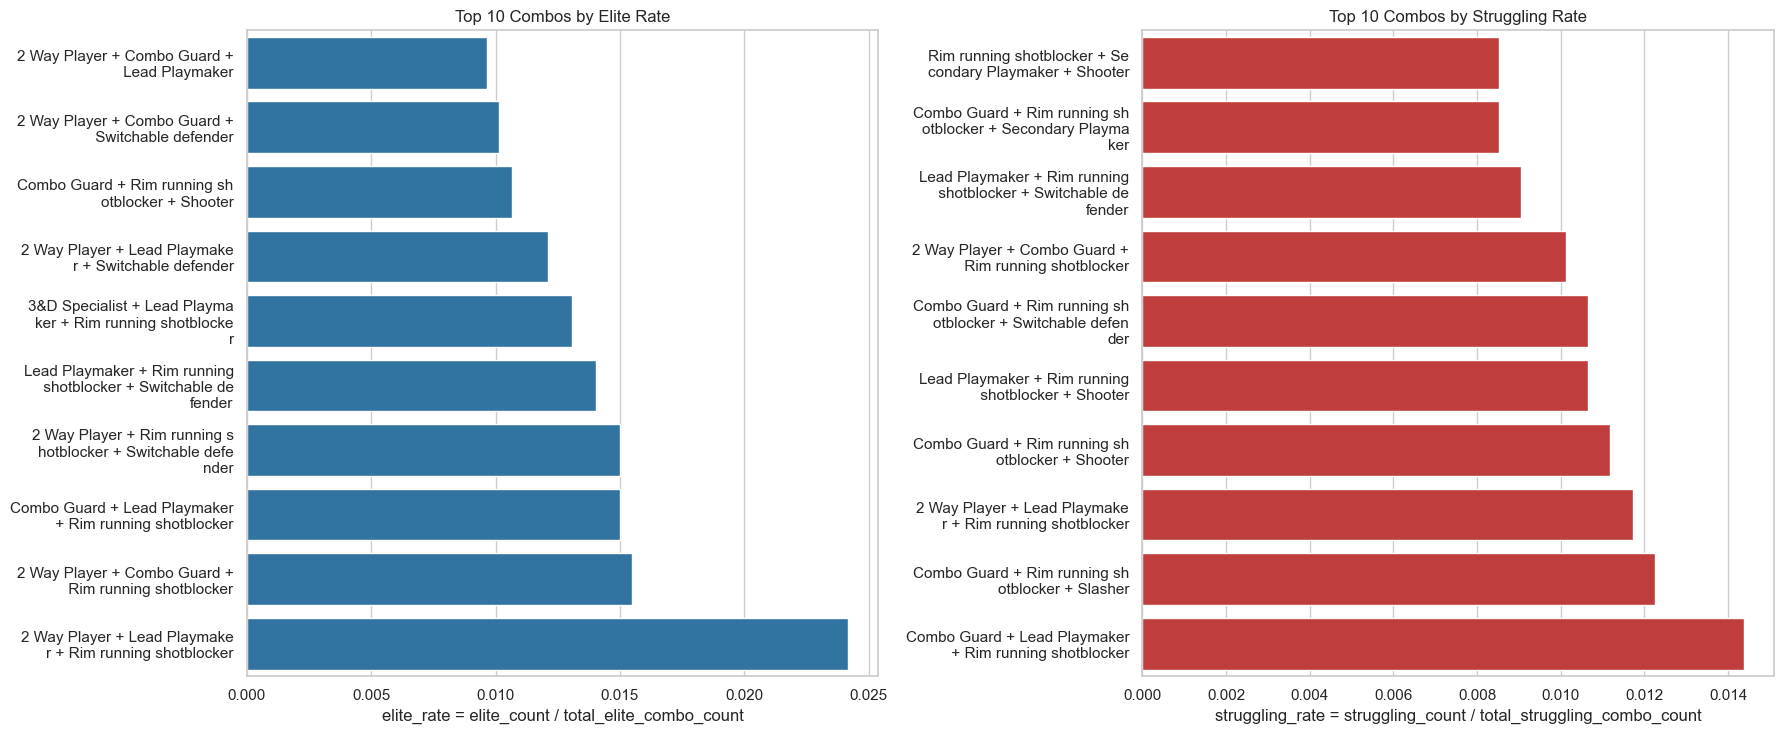

,combo,elite_count,elite_rate
164,2 Way Player + Lead Playmaker + Rim running sh...,50,0.024190
518,2 Way Player + Combo Guard + Rim running shotb...,32,0.015481
63,2 Way Player + Rim running shotblocker + Switc...,31,0.014998
268,Combo Guard + Lead Playmaker + Rim running sho...,31,0.014998
524,Lead Playmaker + Rim running shotblocker + Swi...,29,0.014030
578,3&D Specialist + Lead Playmaker + Rim running ...,27,0.013062
509,2 Way Player + Lead Playmaker + Switchable def...,25,0.012095
196,Combo Guard + Rim running shotblocker + Shooter,22,0.010643
207,2 Way Player + Combo Guard + Switchable defender,21,0.010160
502,2 Way Player + Combo Guard + Lead Playmaker,20,0.009676


,combo,struggling_count,struggling_rate
268,Combo Guard + Lead Playmaker + Rim running sho...,27,0.014377
399,Combo Guard + Rim running shotblocker + Slasher,23,0.012247
164,2 Way Player + Lead Playmaker + Rim running sh...,22,0.011715
196,Combo Guard + Rim running shotblocker + Shooter,21,0.011182
318,Combo Guard + Rim running shotblocker + Switch...,20,0.010650
409,Lead Playmaker + Rim running shotblocker + Sho...,20,0.010650
518,2 Way Player + Combo Guard + Rim running shotb...,19,0.010117
524,Lead Playmaker + Rim running shotblocker + Swi...,17,0.009052
356,Rim running shotblocker + Secondary Playmaker ...,16,0.008520
106,Combo Guard + Rim running shotblocker + Second...,16,0.008520


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# expects: out_df with columns:
# combo, elite_rate, struggling_rate, elite_count, struggling_count

if "out_df" not in globals():
    raise NameError("Expected `out_df` to exist. Run the combo-counting cell first.")

top_n = 10  # combos per side

def wrap_combo(s, width=28):
    s = str(s)
    return "\n".join([s[i:i+width] for i in range(0, len(s), width)])

# Highest elite rate combos (within Elite)
elite_top = out_df.sort_values("elite_rate", ascending=False).head(top_n).copy()
# Highest struggling rate combos (within Struggling)
strug_top = out_df.sort_values("struggling_rate", ascending=False).head(top_n).copy()

elite_top["label_wrapped"] = elite_top["combo"].apply(wrap_combo)
strug_top["label_wrapped"] = strug_top["combo"].apply(wrap_combo)

fig, axes = plt.subplots(1, 2, figsize=(18, 0.45 * top_n + 3))

sns.set(style="whitegrid")

# Elite subplot
sns.barplot(
    ax=axes[0],
    data=elite_top.sort_values("elite_rate", ascending=True),
    x="elite_rate",
    y="label_wrapped",
    color="#1f77b4"
)
axes[0].set_title(f"Top {top_n} Combos by Elite Rate")
axes[0].set_xlabel("elite_rate = elite_count / total_elite_combo_count")
axes[0].set_ylabel("")

# Struggling subplot
sns.barplot(
    ax=axes[1],
    data=strug_top.sort_values("struggling_rate", ascending=True),
    x="struggling_rate",
    y="label_wrapped",
    color="#d62728"
)
axes[1].set_title(f"Top {top_n} Combos by Struggling Rate")
axes[1].set_xlabel("struggling_rate = struggling_count / total_struggling_combo_count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Optional: show the top rows used
display(elite_top[["combo","elite_count","elite_rate"]].head(10))
display(strug_top[["combo","struggling_count","struggling_rate"]].head(10))